# Testing feature importance between descriptors

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.feature_selection import VarianceThreshold

path = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(path)
data_df = df.drop(columns=['Target', 'Refcode', 'Point group'])

In [2]:
df = pd.read_csv(path)
df = df.drop(columns=['Refcode', 'Point group'])
matrix = df.corr()
high_corr_pairs = []

for i in range(len(matrix.columns)):
    for j in range(i + 1, len(matrix.columns)):
        column_value = matrix.iloc[i, j]
        if abs(column_value) > 0.95:
            col1 = matrix.columns[i]
            col2 = matrix.columns[j]
            high_corr_pairs.append((col1, col2))
            print(f"High correlation ({matrix.iloc[i, j]:.2f}) between '{col1}' and '{col2}'")

print(high_corr_pairs)

High correlation (0.98) between 'Number of atoms' and 'Number of bonds'
High correlation (0.98) between 'Number of heavy atoms' and 'Molecular weight'
High correlation (-0.95) between 'Asphericity' and 'Normalised principle moment ratio 1'
High correlation (0.98) between 'Third (largest) principle moment of inertia' and 'Radius of Gyration'
[('Number of atoms', 'Number of bonds'), ('Number of heavy atoms', 'Molecular weight'), ('Asphericity', 'Normalised principle moment ratio 1'), ('Third (largest) principle moment of inertia', 'Radius of Gyration')]


---
As shown, Asphericity and Normalised principle moment ratio 1 as well as 'Third (largest) principle moment of inertia' and 'Radius of Gyration', are two highly correlated pairs so lets test a model with just training these 4.

---

In [14]:
selected_columns = [
    'Number of heteroatoms',
    'Asphericity',
    'Normalised principle moment ratio 1',
    'Molecule Sphericity Index',
    'Target'
]

paired_df = df[selected_columns]
paired_df

,Number of heteroatoms,Asphericity,Normalised principle moment ratio 1,Molecule Sphericity Index,Target
0,0.333333,0.550976,0.196040,0.080138,1.0
1,0.666667,0.158165,0.517727,0.443980,1.0
2,0.666667,0.317360,0.344926,0.383470,1.0
3,0.666667,0.437943,0.286985,0.030993,0.0
4,0.833333,0.157942,0.509085,0.466888,1.0
...,...,...,...,...,...
293,0.333333,0.249904,0.415071,0.569237,1.0
294,0.666667,0.329507,0.342005,0.231570,1.0
295,0.666667,0.323409,0.358083,0.194248,1.0
296,0.333333,0.371266,0.315902,0.502463,1.0


Iteration 1: Accuracy = 38.46%
Iteration 2: Accuracy = 46.15%
Iteration 3: Accuracy = 57.69%
Iteration 4: Accuracy = 65.38%
Iteration 5: Accuracy = 38.46%
Iteration 6: Accuracy = 65.38%
Iteration 7: Accuracy = 57.69%
Iteration 8: Accuracy = 53.85%
Iteration 9: Accuracy = 50.00%
Iteration 10: Accuracy = 38.46%
Iteration 11: Accuracy = 53.85%
Iteration 12: Accuracy = 50.00%
Iteration 13: Accuracy = 61.54%
Iteration 14: Accuracy = 65.38%
Iteration 15: Accuracy = 53.85%
Iteration 16: Accuracy = 53.85%
Iteration 17: Accuracy = 53.85%
Iteration 18: Accuracy = 57.69%
Iteration 19: Accuracy = 61.54%
Iteration 20: Accuracy = 65.38%
Iteration 21: Accuracy = 57.69%
Iteration 22: Accuracy = 46.15%
Iteration 23: Accuracy = 46.15%
Iteration 24: Accuracy = 50.00%
Iteration 25: Accuracy = 57.69%
Iteration 26: Accuracy = 50.00%
Iteration 27: Accuracy = 65.38%
Iteration 28: Accuracy = 46.15%
Iteration 29: Accuracy = 26.92%
Iteration 30: Accuracy = 61.54%
Iteration 31: Accuracy = 57.69%
Iteration 32: Acc

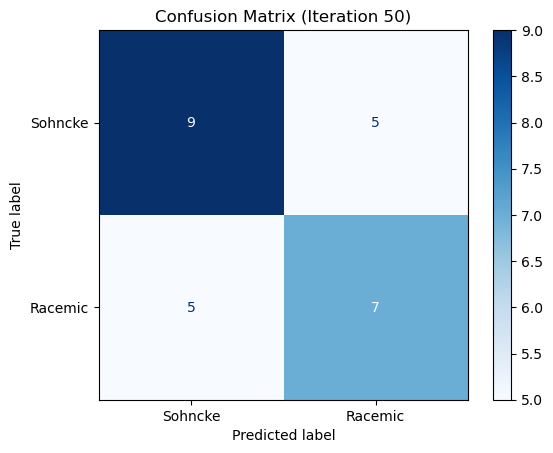

In [16]:
# Number of iterations
num_iterations = 50

# Initialize cumulative accuracy
cumulative_accuracy = 0

for i in range(num_iterations):
    # Load the dataset
    df = paired_df

    # Balancing the dataset
    df_target_0 = df[df['Target'] == 0.0]
    df_target_1 = df[df['Target'] == 1.0]
    rows_df_target_0 = df_target_0.shape[0]
    rows_df_target_1 = df_target_1.shape[0]

    if rows_df_target_0 < rows_df_target_1:
        smaller_df = df_target_0
        larger_df = df_target_1
        smaller_rows = rows_df_target_0
    else:
        smaller_df = df_target_1
        larger_df = df_target_0
        smaller_rows = rows_df_target_1

    scaled_larger_df = larger_df.sample(n=smaller_rows)
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
    shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)

    # Separate features and target
    feature_df = shuffled_balanced_df.drop(columns=['Target'])
    X = np.asarray(feature_df)
    y = np.asarray(shuffled_balanced_df['Target'])

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

    # Perform GridSearchCV to find the optimal parameters
    param_grid = [
        {'C': [0.5, 1, 10, 100],
         'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
         'kernel': ['rbf', 'linear', 'poly']}
    ]

    optimal_params = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy',
        verbose=0
    )

    optimal_params.fit(X_train, y_train)

    # Get the best estimator and fit the model
    classifier = optimal_params.best_estimator_
    classifier.fit(X_train, y_train)

    # Predict the test set
    y_predict = classifier.predict(X_test)

    # Calculate the accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict)
    cumulative_accuracy += accuracy

    # Optionally, print the iteration number and accuracy for tracking progress
    print(f'Iteration {i+1}: Accuracy = {accuracy * 100:.2f}%')

# Calculate the average accuracy
average_accuracy = (cumulative_accuracy / num_iterations) * 100
print(f'Average Accuracy over {num_iterations} iterations: {average_accuracy:.2f}%')

# # Optionally, display the confusion matrix for the last iteration
# ConfusionMatrixDisplay.from_estimator(
#     classifier,
#     X_test,
#     y_test,
#     display_labels=["Sohncke", "Racemic"],
#     cmap=plt.cm.Blues,
#     values_format='d'
# )
# plt.title(f'Confusion Matrix (Iteration {num_iterations})')
# plt.show()


---
Finding the average of averages for 10 runs

---

With all the data

In [18]:
all_df = pd.read_csv(r'filtered and normalised all descriptor data.csv')

In [23]:
# Number of runs
num_runs = 10

# List to store accuracies
all_accuracies = []

for run in range(num_runs):
    # Number of iterations per run
    num_iterations = 50

    # Initialize cumulative accuracy for this run
    cumulative_accuracy = 0

    for i in range(num_iterations):

        df = pd.read_csv(r'filtered and normalised all descriptor data.csv')

        # Balancing the dataset
        df_target_0 = df[df['Target'] == 0.0]
        df_target_1 = df[df['Target'] == 1.0]
        rows_df_target_0 = df_target_0.shape[0]
        rows_df_target_1 = df_target_1.shape[0]

        if rows_df_target_0 < rows_df_target_1:
            smaller_df = df_target_0
            larger_df = df_target_1
            smaller_rows = rows_df_target_0
        else:
            smaller_df = df_target_1
            larger_df = df_target_0
            smaller_rows = rows_df_target_1

        scaled_larger_df = larger_df.sample(n=smaller_rows)
        balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
        shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)

        shuffled_balanced_df = shuffled_balanced_df.drop(columns=['Point group', 'Refcode']) # Cleaning the database and getting rid of any rows that aren't 'float64'
        # Separate features and target
        feature_df = shuffled_balanced_df.drop(columns=['Target'])
        X = np.asarray(feature_df)
        y = np.asarray(shuffled_balanced_df['Target'])

        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

        # Perform GridSearchCV to find the optimal parameters
        param_grid = [
            {'C': [0.5, 1, 10, 100],
             'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
             'kernel': ['rbf', 'linear', 'poly']}
        ]

        optimal_params = GridSearchCV(
            SVC(),
            param_grid,
            cv=5,
            scoring='accuracy',
            verbose=0
        )

        optimal_params.fit(X_train, y_train)

        # Get the best estimator and fit the model
        classifier = optimal_params.best_estimator_
        classifier.fit(X_train, y_train)

        # Predict the test set
        y_predict = classifier.predict(X_test)

        # Calculate the accuracy
        accuracy = metrics.accuracy_score(y_test, y_predict)
        cumulative_accuracy += accuracy

        # Optionally, print the iteration number and accuracy for tracking progress
        print(f'Run {run+1}, Iteration {i+1}: Accuracy = {accuracy * 100:.2f}%')

    # Calculate the average accuracy for this run
    average_accuracy = (cumulative_accuracy / num_iterations) * 100
    print(f'Average Accuracy for Run {run+1}: {average_accuracy:.2f}%')

    # Store this run's average accuracy in the list
    all_accuracies.append(average_accuracy)

# Print all accuracies and the overall average
print("Accuracies from all 10 runs:", all_accuracies)
overall_average_accuracy = np.mean(all_accuracies)
print(f'Overall Average Accuracy across 10 runs: {overall_average_accuracy:.2f}%')

Run 1, Iteration 1: Accuracy = 57.69%
Run 1, Iteration 2: Accuracy = 53.85%
Run 1, Iteration 3: Accuracy = 46.15%
Run 1, Iteration 4: Accuracy = 61.54%
Run 1, Iteration 5: Accuracy = 65.38%
Run 1, Iteration 6: Accuracy = 53.85%
Run 1, Iteration 7: Accuracy = 50.00%
Run 1, Iteration 8: Accuracy = 42.31%
Run 1, Iteration 9: Accuracy = 57.69%
Run 1, Iteration 10: Accuracy = 57.69%
Run 1, Iteration 11: Accuracy = 46.15%
Run 1, Iteration 12: Accuracy = 57.69%
Run 1, Iteration 13: Accuracy = 53.85%
Run 1, Iteration 14: Accuracy = 53.85%
Run 1, Iteration 15: Accuracy = 42.31%
Run 1, Iteration 16: Accuracy = 34.62%
Run 1, Iteration 17: Accuracy = 46.15%
Run 1, Iteration 18: Accuracy = 73.08%
Run 1, Iteration 19: Accuracy = 46.15%
Run 1, Iteration 20: Accuracy = 46.15%
Run 1, Iteration 21: Accuracy = 61.54%
Run 1, Iteration 22: Accuracy = 61.54%
Run 1, Iteration 23: Accuracy = 38.46%
Run 1, Iteration 24: Accuracy = 57.69%
Run 1, Iteration 25: Accuracy = 46.15%
Run 1, Iteration 26: Accuracy = 61

With two pairs with high correlation

In [17]:
# Number of runs
num_runs = 10

# List to store accuracies
all_accuracies = []

for run in range(num_runs):
    # Number of iterations per run
    num_iterations = 50

    # Initialize cumulative accuracy for this run
    cumulative_accuracy = 0

    for i in range(num_iterations):
        # Load the dataset
        df = paired_df

        # Balancing the dataset
        df_target_0 = df[df['Target'] == 0.0]
        df_target_1 = df[df['Target'] == 1.0]
        rows_df_target_0 = df_target_0.shape[0]
        rows_df_target_1 = df_target_1.shape[0]

        if rows_df_target_0 < rows_df_target_1:
            smaller_df = df_target_0
            larger_df = df_target_1
            smaller_rows = rows_df_target_0
        else:
            smaller_df = df_target_1
            larger_df = df_target_0
            smaller_rows = rows_df_target_1

        scaled_larger_df = larger_df.sample(n=smaller_rows)
        balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
        shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)

        # Separate features and target
        feature_df = shuffled_balanced_df.drop(columns=['Target'])
        X = np.asarray(feature_df)
        y = np.asarray(shuffled_balanced_df['Target'])

        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

        # Perform GridSearchCV to find the optimal parameters
        param_grid = [
            {'C': [0.5, 1, 10, 100],
             'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
             'kernel': ['rbf', 'linear', 'poly']}
        ]

        optimal_params = GridSearchCV(
            SVC(),
            param_grid,
            cv=5,
            scoring='accuracy',
            verbose=0
        )

        optimal_params.fit(X_train, y_train)

        # Get the best estimator and fit the model
        classifier = optimal_params.best_estimator_
        classifier.fit(X_train, y_train)

        # Predict the test set
        y_predict = classifier.predict(X_test)

        # Calculate the accuracy
        accuracy = metrics.accuracy_score(y_test, y_predict)
        cumulative_accuracy += accuracy

        # Optionally, print the iteration number and accuracy for tracking progress
        print(f'Run {run+1}, Iteration {i+1}: Accuracy = {accuracy * 100:.2f}%')

    # Calculate the average accuracy for this run
    average_accuracy = (cumulative_accuracy / num_iterations) * 100
    print(f'Average Accuracy for Run {run+1}: {average_accuracy:.2f}%')

    # Store this run's average accuracy in the list
    all_accuracies.append(average_accuracy)

# Print all accuracies and the overall average
print("Accuracies from all 10 runs:", all_accuracies)
overall_average_accuracy = np.mean(all_accuracies)
print(f'Overall Average Accuracy across 10 runs: {overall_average_accuracy:.2f}%')


Run 1, Iteration 1: Accuracy = 46.15%
Run 1, Iteration 2: Accuracy = 69.23%
Run 1, Iteration 3: Accuracy = 61.54%
Run 1, Iteration 4: Accuracy = 46.15%
Run 1, Iteration 5: Accuracy = 61.54%
Run 1, Iteration 6: Accuracy = 42.31%
Run 1, Iteration 7: Accuracy = 53.85%
Run 1, Iteration 8: Accuracy = 69.23%
Run 1, Iteration 9: Accuracy = 61.54%
Run 1, Iteration 10: Accuracy = 34.62%
Run 1, Iteration 11: Accuracy = 38.46%
Run 1, Iteration 12: Accuracy = 57.69%
Run 1, Iteration 13: Accuracy = 50.00%
Run 1, Iteration 14: Accuracy = 50.00%
Run 1, Iteration 15: Accuracy = 42.31%
Run 1, Iteration 16: Accuracy = 53.85%
Run 1, Iteration 17: Accuracy = 50.00%
Run 1, Iteration 18: Accuracy = 57.69%
Run 1, Iteration 19: Accuracy = 38.46%
Run 1, Iteration 20: Accuracy = 65.38%
Run 1, Iteration 21: Accuracy = 50.00%
Run 1, Iteration 22: Accuracy = 50.00%
Run 1, Iteration 23: Accuracy = 80.77%
Run 1, Iteration 24: Accuracy = 42.31%
Run 1, Iteration 25: Accuracy = 50.00%
Run 1, Iteration 26: Accuracy = 65